# Fair Comparative Benchmark: Standard RCE vs ResNet-18

**Scene:** `artroom1` — LEFT (im0) for training, RIGHT (im1) for detection.

**Object ROI:** `x=400, y=700, 300×300` (user-defined region on the left image).

**Fairness guarantees:**
| Aspect | RCE | ResNet-18 |
|--------|-----|-----------|
| **Input** | Raw RGB pixels (3-D) | 224×224 normalised patch → 512-D frozen features |
| **Classifier** | Prototype spheres (trained from scratch) | Logistic Regression on pre-trained features |
| **Training data** | Pixel colours sampled from ROI + background | Image patches cropped from ROI + background |
| **Training time** | End-to-end (pixel collection + fit) | End-to-end (feature extraction + LR fit) |
| **Detection** | Same sliding window, stride, conf threshold, NMS | Same sliding window, stride, conf threshold, NMS |
| **Evaluation** | Same GT box, same IoU threshold | Same GT box, same IoU threshold |

**Key difference being measured:** A lightweight, interpretable, from-scratch prototype classifier (RCE) vs a heavyweight pre-trained deep feature extractor (ResNet-18).

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "middlebury").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from RCE.loader import load_stereo_pair
from RCE.rce import RCE

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.linear_model import LogisticRegression

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  Project: {PROJECT_ROOT}")

Device: mps  |  Project: /Volumes/T7/RecognitionBenchmark


## 1. Load scene & define ROI

Scene: artroom1  |  Image: 1920×1080


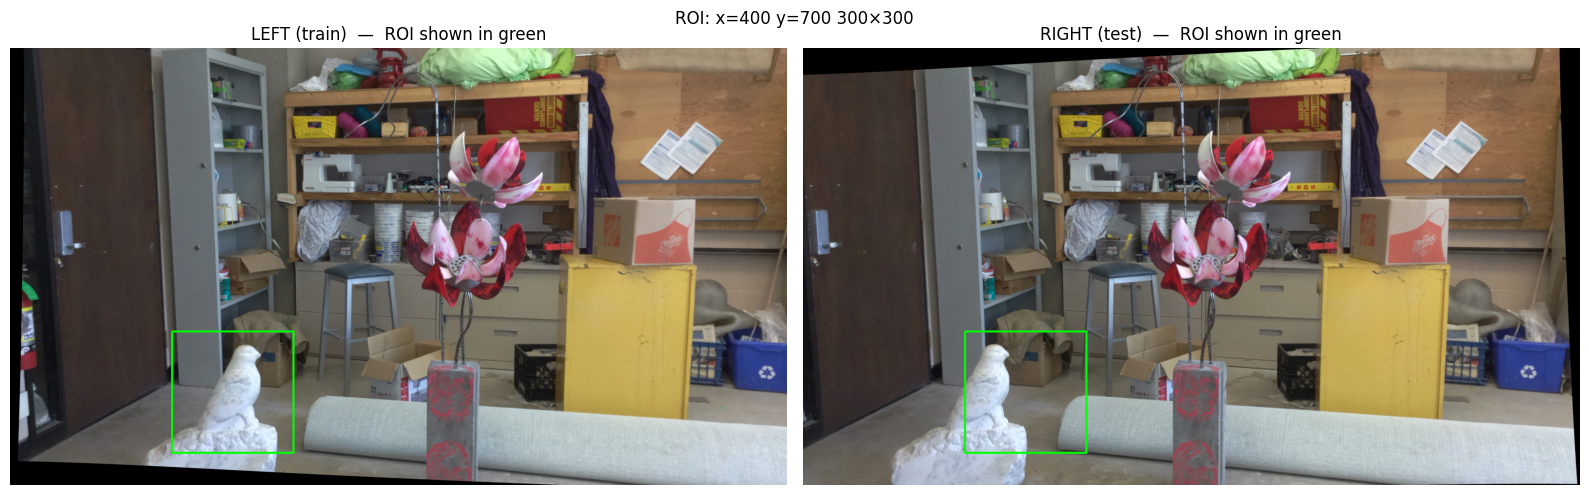

In [2]:
DATA_ROOT = PROJECT_ROOT / "data" / "middlebury"
SCENE = "artroom1"
pair = load_stereo_pair(DATA_ROOT, SCENE)
img_left = pair["left"]    # train
img_right = pair["right"]  # test
H, W = img_left.shape[:2]
print(f"Scene: {SCENE}  |  Image: {W}×{H}")

# User-defined ROI on the LEFT image
ROI_X, ROI_Y, ROI_W, ROI_H = 400, 700, 300, 300
gt_box = (ROI_X, ROI_Y, ROI_X + ROI_W, ROI_Y + ROI_H)  # (x1,y1,x2,y2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, img, title in [(axes[0], img_left, "LEFT (train)"), (axes[1], img_right, "RIGHT (test)")]:
    vis = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
    cv2.rectangle(vis, (ROI_X, ROI_Y), (ROI_X+ROI_W, ROI_Y+ROI_H), (0, 255, 0), 3)
    ax.imshow(vis)
    ax.set_title(f"{title}  —  ROI shown in green")
    ax.axis("off")
plt.suptitle(f"ROI: x={ROI_X} y={ROI_Y} {ROI_W}×{ROI_H}", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Configuration

In [3]:
STRIDE       = 75          # sliding window step (same for both)
CONF_THRESH  = 0.5         # detection confidence threshold
NMS_IOU      = 0.3         # NMS overlap threshold
IOU_EVAL     = 0.5         # evaluation IoU threshold
RCE_R_MAX    = 80.0        # max prototype radius
RCE_N_OBJ    = 1500        # object pixel samples for RCE training
RCE_N_BG     = 1500        # background pixel samples for RCE training
RESNET_N_NEG = 30          # negative patches for ResNet head training
SEED         = 42
rng = np.random.default_rng(SEED)

def iou_score(a, b):
    """IoU between two (x1,y1,x2,y2) boxes."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-6)

def greedy_nms(dets, iou_thresh):
    """NMS on list of (x1,y1,x2,y2,label,conf)."""
    dets = sorted(dets, key=lambda d: d[5], reverse=True)
    keep = []
    while dets:
        best = dets.pop(0)
        keep.append(best)
        dets = [d for d in dets if iou_score(best[:4], d[:4]) < iou_thresh]
    return keep

print("Config ready.")

Config ready.


## 3. Train RCE (end-to-end timed)

RCE operates on raw pixel colours (3-D vectors). We sample pixels from the ROI (object) and from outside (background), then fit the prototype network.

Total time = pixel sampling + `rce.fit()`.

In [4]:
t_rce_start = time.perf_counter()

# Sample object pixels from ROI
roi_crop = img_left[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W]
obj_pixels = roi_crop.reshape(-1, 3).astype(np.float64)
if len(obj_pixels) > RCE_N_OBJ:
    idx = rng.choice(len(obj_pixels), RCE_N_OBJ, replace=False)
    obj_pixels = obj_pixels[idx]

# Sample background pixels from outside ROI
mask_bg = np.ones((H, W), dtype=bool)
mask_bg[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W] = False
bg_all = img_left[mask_bg].astype(np.float64)
if len(bg_all) > RCE_N_BG:
    idx = rng.choice(len(bg_all), RCE_N_BG, replace=False)
    bg_pixels = bg_all[idx]
else:
    bg_pixels = bg_all

X_rce = np.vstack([obj_pixels, bg_pixels])
y_rce = np.concatenate([np.full(len(obj_pixels), "object"),
                         np.full(len(bg_pixels), "background")])

rce = RCE(R_max=RCE_R_MAX, default_label="background")
rce.fit(X_rce, y_rce)

t_rce_train = (time.perf_counter() - t_rce_start) * 1000

print(f"RCE training (end-to-end): {t_rce_train:.0f} ms")
print(f"  Samples: {len(obj_pixels)} object + {len(bg_pixels)} background = {len(X_rce)}")
print(f"  Prototypes: {len(rce.centers_)}")

RCE training (end-to-end): 133 ms
  Samples: 1500 object + 1500 background = 3000
  Prototypes: 829


## 4. Train ResNet-18 head (end-to-end timed)

ResNet operates on image patches. We crop the ROI (+ augmented flip) as positives, sample random non-overlapping patches as negatives, extract 512-D features through the frozen backbone, then fit a Logistic Regression.

Total time = patch cropping + ResNet forward passes + `LR.fit()`.

In [5]:
_IMAGENET_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
_resnet_full = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
_resnet_full.eval()
for p in _resnet_full.parameters():
    p.requires_grad = False
_resnet_extractor = torch.nn.Sequential(*list(_resnet_full.children())[:-1]).to(DEVICE)

def resnet_features(img_bgr):
    """512-D feature vector from a BGR image patch."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    t = _IMAGENET_TRANSFORM(rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return _resnet_extractor(t).cpu().numpy().flatten()

# --- End-to-end timed training ---
t_resnet_start = time.perf_counter()

pos_patches = [roi_crop, cv2.flip(roi_crop, 1)]
neg_patches = []
attempts = 0
while len(neg_patches) < RESNET_N_NEG and attempts < 500:
    nx = rng.integers(0, max(1, W - ROI_W))
    ny = rng.integers(0, max(1, H - ROI_H))
    if iou_score((nx, ny, nx+ROI_W, ny+ROI_H), gt_box) < 0.3:
        neg_patches.append(img_left[ny:ny+ROI_H, nx:nx+ROI_W])
    attempts += 1

all_patches = pos_patches + neg_patches
all_labels = ["object"] * len(pos_patches) + ["background"] * len(neg_patches)

X_resnet = np.array([resnet_features(p) for p in all_patches])
resnet_head = LogisticRegression(C=1.0, max_iter=1000)
resnet_head.fit(X_resnet, all_labels)

t_resnet_train = (time.perf_counter() - t_resnet_start) * 1000

print(f"ResNet training (end-to-end): {t_resnet_train:.0f} ms")
print(f"  Patches: {len(pos_patches)} pos + {len(neg_patches)} neg = {len(all_patches)}")
print(f"  Feature extraction: {len(all_patches)} × ResNet forward pass")
print(f"  Feature dim: {X_resnet.shape[1]}")

ResNet training (end-to-end): 1037 ms
  Patches: 2 pos + 30 neg = 32
  Feature extraction: 32 × ResNet forward pass
  Feature dim: 512


## 5. Detection on the RIGHT image (identical sliding window)

Both methods scan the same grid of windows. Only the per-window classification differs:
- **RCE:** Sample pixels from the window, classify each pixel, confidence = fraction labelled "object".
- **ResNet:** Resize window to 224×224, extract 512-D features, LR predicts probability of "object".

In [6]:
Hr, Wr = img_right.shape[:2]
ys = list(range(0, Hr - ROI_H + 1, STRIDE))
xs = list(range(0, Wr - ROI_W + 1, STRIDE))
n_windows = len(ys) * len(xs)
print(f"Sliding window: {ROI_W}×{ROI_H}, stride={STRIDE}, grid={len(xs)}×{len(ys)} = {n_windows} windows")

# Pre-build the pixel sub-grid for RCE (14×14 = 196 samples per window)
grid_side = 14
gr = np.linspace(0, ROI_H - 1, grid_side, dtype=int)
gc = np.linspace(0, ROI_W - 1, grid_side, dtype=int)
grr, gcc = np.meshgrid(gr, gc, indexing="ij")
grr, gcc = grr.ravel(), gcc.ravel()
spw = len(grr)
print(f"RCE pixels per window: {spw}")

# ---- RCE detection (batched) ----
# Collect all window pixels into one array, run one batched cdist
all_pixels = np.empty((n_windows * spw, 3), dtype=np.float64)
positions = []
idx = 0
for y in ys:
    for x in xs:
        all_pixels[idx:idx+spw] = img_right[grr + y, gcc + x].astype(np.float64)
        positions.append((x, y))
        idx += spw

C = rce.centers_
R = rce.radii_
L = rce.labels_
obj_proto_mask = (L == "object")

t_rce_det_start = time.perf_counter()

chunk = 50000
is_obj = np.empty(len(all_pixels), dtype=bool)
for s in range(0, len(all_pixels), chunk):
    e = min(s + chunk, len(all_pixels))
    D = cdist(all_pixels[s:e], C, metric="euclidean")
    D_masked = np.where(D < R[np.newaxis, :], D, np.inf)
    best_idx = np.argmin(D_masked, axis=1)
    best_d = D_masked[np.arange(e - s), best_idx]
    is_obj[s:e] = (best_d < np.inf) & obj_proto_mask[best_idx]

confs_rce = is_obj.reshape(n_windows, spw).mean(axis=1)

rce_dets = []
for wi in range(n_windows):
    if confs_rce[wi] >= CONF_THRESH:
        x, y = positions[wi]
        rce_dets.append((x, y, x + ROI_W, y + ROI_H, "object", float(confs_rce[wi])))

t_rce_detect = (time.perf_counter() - t_rce_det_start) * 1000
rce_dets = greedy_nms(rce_dets, NMS_IOU) if rce_dets else []
print(f"\nRCE  detection: {t_rce_detect:.0f} ms  →  {len(rce_dets)} detections (after NMS)")

# ---- ResNet detection ----
resnet_dets = []
obj_class_idx = np.where(resnet_head.classes_ == "object")[0]

t_resnet_det_start = time.perf_counter()

for y in ys:
    for x in xs:
        patch = img_right[y:y+ROI_H, x:x+ROI_W]
        feats = resnet_features(patch)
        probs = resnet_head.predict_proba([feats])[0]
        if len(obj_class_idx) == 0:
            continue
        conf = float(probs[obj_class_idx[0]])
        if conf >= CONF_THRESH:
            resnet_dets.append((x, y, x + ROI_W, y + ROI_H, "object", conf))

t_resnet_detect = (time.perf_counter() - t_resnet_det_start) * 1000
resnet_dets = greedy_nms(resnet_dets, NMS_IOU) if resnet_dets else []
print(f"ResNet detection: {t_resnet_detect:.0f} ms  →  {len(resnet_dets)} detections (after NMS)")

Sliding window: 300×300, stride=75, grid=22×11 = 242 windows
RCE pixels per window: 196

RCE  detection: 575 ms  →  4 detections (after NMS)
ResNet detection: 3123 ms  →  1 detections (after NMS)


## 6. Evaluation & visualisation

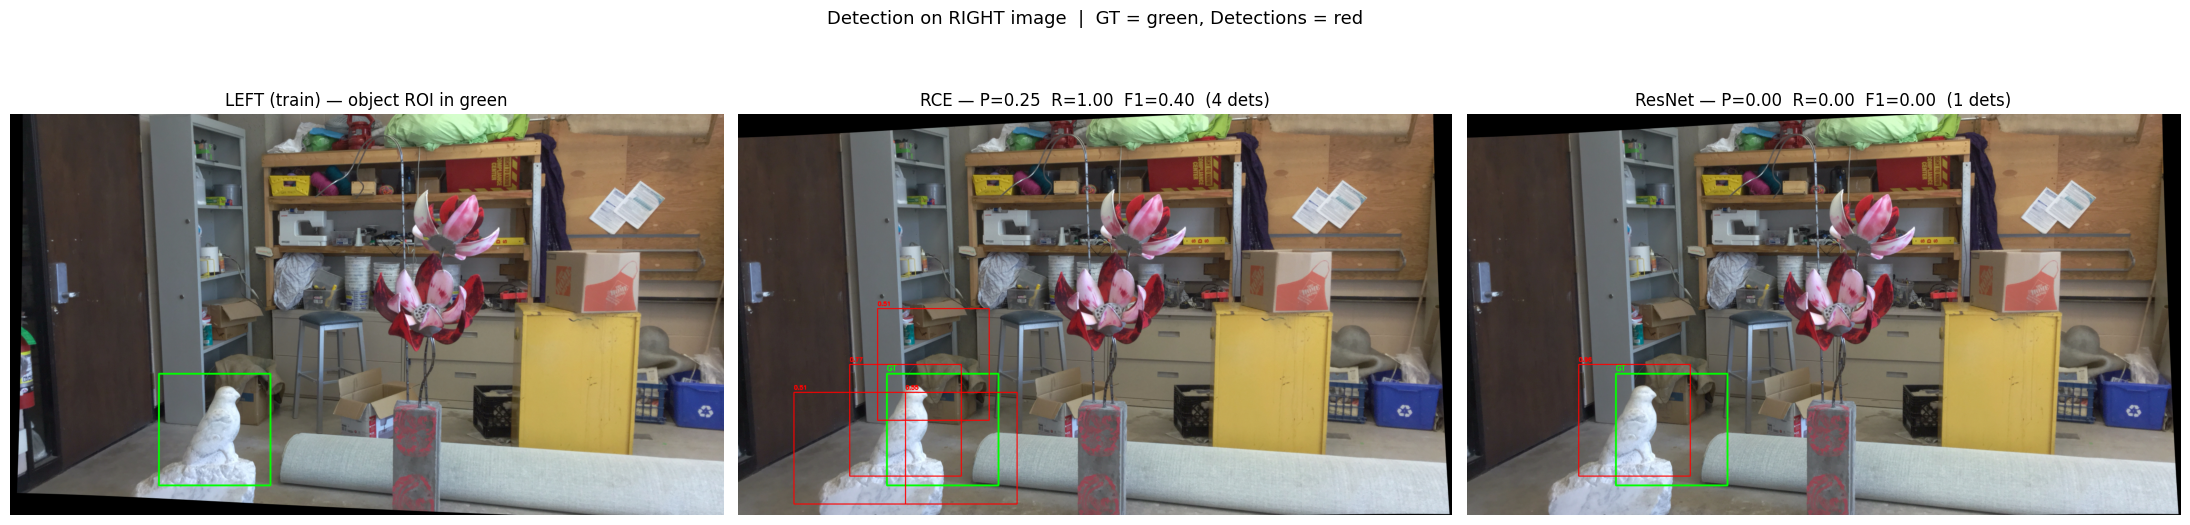

In [7]:
def eval_dets(dets, gt, iou_thresh):
    if not dets:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "n_dets": 0, "best_iou": 0.0}
    ious = [iou_score(d[:4], gt) for d in dets]
    best_iou = max(ious)
    tp = sum(1 for i in ious if i >= iou_thresh)
    fp = len(dets) - tp
    fn = 0 if tp > 0 else 1
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0.0
    return {"precision": prec, "recall": rec, "f1": f1, "n_dets": len(dets), "best_iou": best_iou}

rce_metrics = eval_dets(rce_dets, gt_box, IOU_EVAL)
resnet_metrics = eval_dets(resnet_dets, gt_box, IOU_EVAL)

def draw_dets(img_bgr, dets, gt, title):
    vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    cv2.rectangle(vis, (gt[0], gt[1]), (gt[2], gt[3]), (0, 255, 0), 3)
    cv2.putText(vis, "GT", (gt[0], gt[1]-8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    for d in dets:
        cv2.rectangle(vis, (d[0], d[1]), (d[2], d[3]), (255, 0, 0), 2)
        cv2.putText(vis, f"{d[5]:.2f}", (d[0], d[1]-8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
    return vis

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Left image with ROI
vis_left = cv2.cvtColor(img_left.copy(), cv2.COLOR_BGR2RGB)
cv2.rectangle(vis_left, (ROI_X, ROI_Y), (ROI_X+ROI_W, ROI_Y+ROI_H), (0, 255, 0), 3)
axes[0].imshow(vis_left)
axes[0].set_title("LEFT (train) — object ROI in green")
axes[0].axis("off")

# RCE detections
vis_rce = draw_dets(img_right, rce_dets, gt_box, "RCE")
axes[1].imshow(vis_rce)
axes[1].set_title(f"RCE — P={rce_metrics['precision']:.2f}  R={rce_metrics['recall']:.2f}  "
                  f"F1={rce_metrics['f1']:.2f}  ({rce_metrics['n_dets']} dets)")
axes[1].axis("off")

# ResNet detections
vis_resnet = draw_dets(img_right, resnet_dets, gt_box, "ResNet")
axes[2].imshow(vis_resnet)
axes[2].set_title(f"ResNet — P={resnet_metrics['precision']:.2f}  R={resnet_metrics['recall']:.2f}  "
                  f"F1={resnet_metrics['f1']:.2f}  ({resnet_metrics['n_dets']} dets)")
axes[2].axis("off")

plt.suptitle(f"Detection on RIGHT image  |  GT = green, Detections = red", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Timing comparison

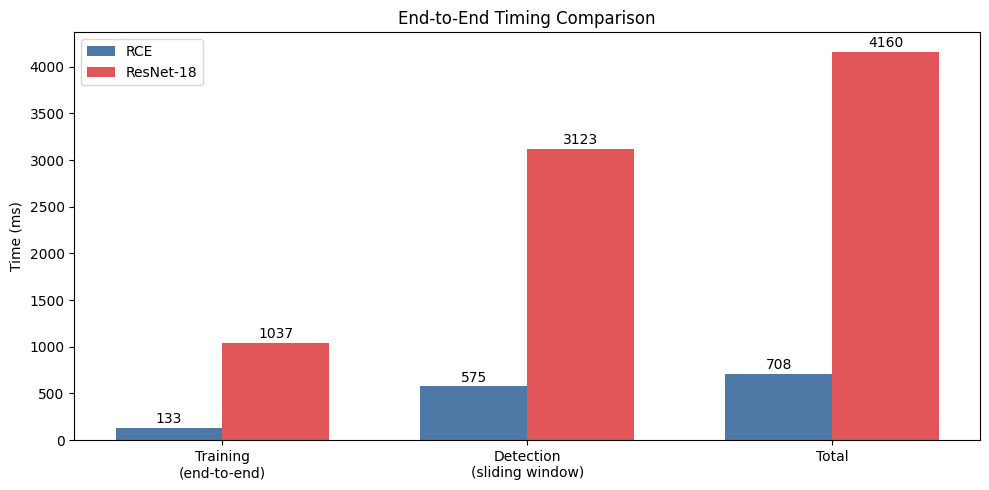

In [8]:
labels = ["Training\n(end-to-end)", "Detection\n(sliding window)", "Total"]
rce_times   = [t_rce_train, t_rce_detect, t_rce_train + t_rce_detect]
resnet_times = [t_resnet_train, t_resnet_detect, t_resnet_train + t_resnet_detect]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rce_times, width, label="RCE", color="#4e79a7")
bars2 = ax.bar(x + width/2, resnet_times, width, label="ResNet-18", color="#e15759")

for bars in [bars1, bars2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
                f"{b.get_height():.0f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Time (ms)")
ax.set_title("End-to-End Timing Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary

In [9]:
print(f"""
{'='*65}
FAIR BENCHMARK SUMMARY — {SCENE}
ROI: x={ROI_X} y={ROI_Y} {ROI_W}×{ROI_H}
{'='*65}

                         RCE              ResNet-18
─────────────────────────────────────────────────────
Architecture       Prototype spheres    Frozen CNN + LR
Feature dim        3 (raw RGB)          512 (ImageNet)
Training samples   {len(X_rce):>5}               {len(all_patches):>5}
Prototypes/Params  {len(rce.centers_):>5}               N/A (pretrained)

TRAINING (end-to-end)
  Time             {t_rce_train:>8.0f} ms         {t_resnet_train:>8.0f} ms

DETECTION ({n_windows} windows, stride={STRIDE})
  Time             {t_rce_detect:>8.0f} ms         {t_resnet_detect:>8.0f} ms
  Detections       {rce_metrics['n_dets']:>8d}              {resnet_metrics['n_dets']:>8d}

TOTAL TIME
                   {t_rce_train+t_rce_detect:>8.0f} ms         {t_resnet_train+t_resnet_detect:>8.0f} ms

ACCURACY (IoU ≥ {IOU_EVAL})
  Precision        {rce_metrics['precision']:>8.3f}              {resnet_metrics['precision']:>8.3f}
  Recall           {rce_metrics['recall']:>8.3f}              {resnet_metrics['recall']:>8.3f}
  F1               {rce_metrics['f1']:>8.3f}              {resnet_metrics['f1']:>8.3f}
  Best IoU         {rce_metrics['best_iou']:>8.3f}              {resnet_metrics['best_iou']:>8.3f}
{'='*65}

FAIRNESS NOTES
- Both use identical sliding window ({ROI_W}×{ROI_H}, stride={STRIDE})
- Both use identical NMS (IoU={NMS_IOU}) and conf threshold ({CONF_THRESH})
- Both evaluated against the same GT box
- Training times are END-TO-END (including feature extraction for ResNet)
- RCE trains from scratch on raw pixel data (no pre-training)
- ResNet leverages ImageNet pre-trained features (transfer learning)
""")


FAIR BENCHMARK SUMMARY — artroom1
ROI: x=400 y=700 300×300

                         RCE              ResNet-18
─────────────────────────────────────────────────────
Architecture       Prototype spheres    Frozen CNN + LR
Feature dim        3 (raw RGB)          512 (ImageNet)
Training samples    3000                  32
Prototypes/Params    829               N/A (pretrained)

TRAINING (end-to-end)
  Time                  133 ms             1037 ms

DETECTION (242 windows, stride=75)
  Time                  575 ms             3123 ms
  Detections              4                     1

TOTAL TIME
                        708 ms             4160 ms

ACCURACY (IoU ≥ 0.5)
  Precision           0.250                 0.000
  Recall              1.000                 0.000
  F1                  0.400                 0.000
  Best IoU            0.532                 0.440

FAIRNESS NOTES
- Both use identical sliding window (300×300, stride=75)
- Both use identical NMS (IoU=0.3) and conf threshol